# Lab5 - Introduction to Deep Neural Network
- Jiraphan Sakpisuttipong, 66070501009
- Pemika Chongkwanyuen, 66070501034
- Siraprapa Chinwongtan, 66070501055

Name your file to 34xx_34xx.ipynb

## Lab Instruction

In this lab, you will learn how to build a simple fully-connected neural network with Keras and Tensorflow as the backend. We will experiment with MNIST data, which is a Keras built-in dataset.

There are three questions to answer in this lab.

See http://yann.lecun.com/exdb/mnist/ for data description.

First, import all of the libraries that will be used in this lab.

In [ ]:
import keras
import numpy as np

In [ ]:
from keras.datasets import mnist
from keras import models, layers, optimizers

# โหลด MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### 1. Learn About the Data

Understand your data, such as its shape, format, datatype, structure, distribution, data classes, and so on.

In [ ]:
# ตรวจรูปร่าง/ชนิดข้อมูล/ช่วงค่า
print("x_train shape:", x_train.shape, "dtype:", x_train.dtype, "min/max:", x_train.min(), x_train.max())
print("y_train shape:", y_train.shape, "classes:", np.unique(y_train))
print("x_test  shape:", x_test.shape)
print("y_test  shape:", y_test.shape)

# ดูตัวอย่างหนึ่งภาพ
idx = 0
print("Sample label:", y_train[idx])

x_train shape: (60000, 28, 28) dtype: uint8 min/max: 0 255
y_train shape: (60000,) classes: [0 1 2 3 4 5 6 7 8 9]
x_test  shape: (10000, 28, 28)
y_test  shape: (10000,)
Sample label: 5


### 2. Build Neural Network Model

Build a two-layer neural network (except for the input and output layers) using `Sequential()`
( See https://keras.io/models/sequential )
> INPUT -> LINEAR -> RELU -> LINEAR -> SOFTMAX

with the hidden layer of size 512.

See Keras Model: https://keras.io/models/about-keras-models/

In [ ]:
model = models.Sequential([
    layers.Input(shape=(784,)),           # flatten แล้วค่อย feed เข้า (ดูข้อ 3)
    layers.Dense(512, activation='relu'), # LINEAR -> ReLU
    layers.Dense(10, activation='softmax')# LINEAR -> Softmax (10 classes)
])

Compile your model with the following argument.

```
optimizer='sgd',
loss='categorical_crossentropy',
metrics=['accuracy']
```

In [ ]:
model.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Let's see how our model looks using `.summary()`

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

### 3. Preprocessing

- Reshape (flatten) the features data and normalize the value to be between 0 and 1
- One-hot the target data

In [ ]:
# flatten และ normalize
x_train_flat = x_train.reshape((x_train.shape[0], -1)).astype("float32") / 255.0
x_test_flat  = x_test.reshape((x_test.shape[0], -1)).astype("float32") / 255.0

# one-hot
num_classes = 10
y_train_oh = keras.utils.to_categorical(y_train, num_classes)
y_test_oh  = keras.utils.to_categorical(y_test,  num_classes)

print(x_train_flat.shape, y_train_oh.shape)


(60000, 784) (60000, 10)


### 4. Model Training

Use `.fit()` to train your neural network model and return a record of accuracy and loss values for each epoch.

We will train the model for 10 epochs (If you are confident in your computer's performance, you can train the model with more epochs.)

We will train using the mini-batch method, with each batch containing 128 data points.

To avoid overfitting with the test set, we will split the current training data into 90% for training and 10% for validating the model.

This will take approximately one minute.

In [ ]:
history = model.fit(
    x_train_flat, y_train_oh,
    epochs=10,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.5773 - loss: 1.5988 - val_accuracy: 0.8852 - val_loss: 0.5969
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8602 - loss: 0.6124 - val_accuracy: 0.9050 - val_loss: 0.4071
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8817 - loss: 0.4633 - val_accuracy: 0.9142 - val_loss: 0.3440
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8942 - loss: 0.4003 - val_accuracy: 0.9213 - val_loss: 0.3088
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9012 - loss: 0.3652 - val_accuracy: 0.9250 - val_loss: 0.2863
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9056 - loss: 0.3426 - val_accuracy: 0.9278 - val_loss: 0.2715
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9075 - loss: 0.3333 - val_accuracy: 0.9300 - val_loss: 0.2581
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9124 - loss: 0.3148 - val_accuracy: 0.

We will plot the loss and accuracy of both the train and validate sets over iterations.

In [ ]:
import  matplotlib.pyplot  as plt
%matplotlib inline

In [ ]:
# The function argument is the model's history during the training process.
def plot_loss(history):
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)

    plt.figure()
    plt.plot(epochs, loss, marker='o', label='Training loss')
    plt.plot(epochs, val_loss, label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

def plot_acc(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    epochs = range(1, len(acc) + 1)

    plt.figure()
    plt.plot(epochs, acc, marker='o', label='Training accuracy')
    plt.plot(epochs, val_acc, label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

In [ ]:
history.history

{'accuracy': [0.7325925827026367,
  0.8661666512489319,
  0.8857592344284058,
  0.8948147892951965,
  0.9014999866485596,
  0.9064815044403076,
  0.9105740785598755,
  0.9137592315673828,
  0.9167592525482178,
  0.9193703532218933],
 'loss': [1.168633222579956,
  0.5601709485054016,
  0.4447791576385498,
  0.39306679368019104,
  0.36184945702552795,
  0.3398298919200897,
  0.3230089247226715,
  0.3092735707759857,
  0.2978343069553375,
  0.2876051068305969],
 'val_accuracy': [0.8851666450500488,
  0.9049999713897705,
  0.9141666889190674,
  0.9213333129882812,
  0.925000011920929,
  0.9278333187103271,
  0.9300000071525574,
  0.9321666955947876,
  0.9351666569709778,
  0.9359999895095825],
 'val_loss': [0.596880316734314,
  0.40713492035865784,
  0.343960702419281,
  0.30878138542175293,
  0.286339670419693,
  0.271487295627594,
  0.2581063210964203,
  0.2487773448228836,
  0.2397346794605255,
  0.23188869655132294]}

In [ ]:
gap = []
for i in range(0, 10):
    gap.append(history.history['val_accuracy'][i] - history.history['accuracy'][i])

print("Change in gap between validation and training accuracy per epoch:")
for i in range(1, 10):
    if gap[i] < gap[i-1]:
        print(f"Epoch {i+1}: Decrease in gap")
    else:
        print(f"Epoch {i+1}: Increase or no change in gap")

Change in gap between validation and training accuracy per epoch:
Epoch 2: Decrease in gap
Epoch 3: Decrease in gap
Epoch 4: Decrease in gap
Epoch 5: Decrease in gap
Epoch 6: Decrease in gap
Epoch 7: Decrease in gap
Epoch 8: Decrease in gap
Epoch 9: Decrease in gap
Epoch 10: Decrease in gap


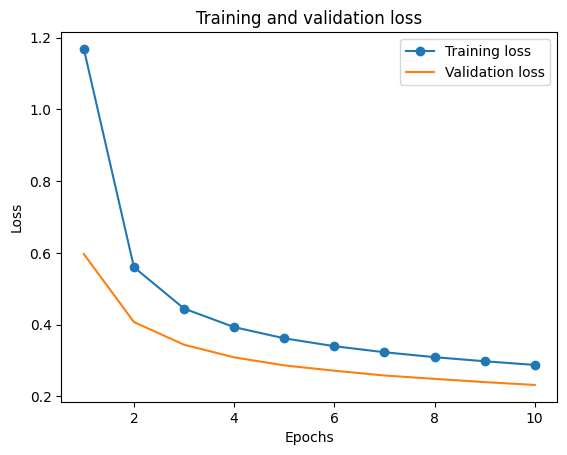

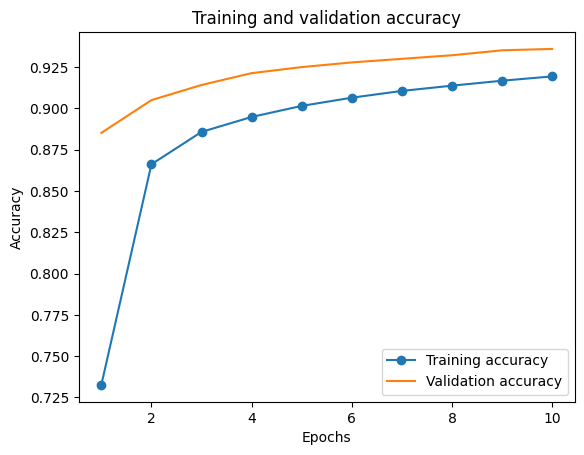

In [ ]:
plot_loss(history)
plot_acc(history)

Q: At which iteration does your model start to overfit? Give your rational.

**ANSWER** The model does NOT show signs of overfitting within these 10 epochs.

Based on the training history, overfitting starts when the validation loss begins to increase while the training loss continues to decrease, or when the gap between training and validation accuracy starts to widen significantly. Looking at the output of cell above, the gap between training and validation accuracy is decreasing throughout the 10 epochs, and the validation loss is also decreasing (as shown in the plot). **This indicates that the model has not started to overfit within these 10 epochs.**

### 5. Model Evaluation

Evaluate your model with test set using `.evaluate()` and compare the results to those from the training and validate sets. Does your model overfit or underfit? How about the bias and variance?

In [ ]:
test_loss, test_acc = model.evaluate(x_test_flat, y_test_oh, verbose=0)
print(f"Test loss: {test_loss:.4f}  |  Test accuracy: {test_acc:.4f}")

Test loss: 0.2676  |  Test accuracy: 0.9258


Q: Analyze the performance of your model using a confusion matrix. Which class does your model frequently misclassify? What is the precision and recall of your model?

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

### evaluate your model ###

# พยากรณ์คลาสบน test
y_prob = model.predict(x_test_flat, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = y_test

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

# รายงาน precision/recall/f1 ต่อคลาส
print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

Confusion Matrix:
 [[ 964    0    1    2    0    3    6    1    3    0]
 [   0 1111    2    2    0    0    4    2   14    0]
 [  10    3  920   15   15    1   13   14   35    6]
 [   3    1   19  928    0   18    2   12   19    8]
 [   1    4    5    0  913    0    9    2    8   40]
 [  12    2    6   31    7  786   12    4   25    7]
 [  14    3    4    2   16    8  905    1    5    0]
 [   2   12   25    4   10    0    0  937    4   34]
 [   8    5    7   18    7   14   12   10  881   12]
 [  11    7    2   12   36    8    1   13    6  913]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9405    0.9837    0.9616       980
           1     0.9678    0.9789    0.9733      1135
           2     0.9284    0.8915    0.9095      1032
           3     0.9152    0.9188    0.9170      1010
           4     0.9094    0.9297    0.9194       982
           5     0.9379    0.8812    0.9087       892
           6     0.9388    0.9447    0.9417    

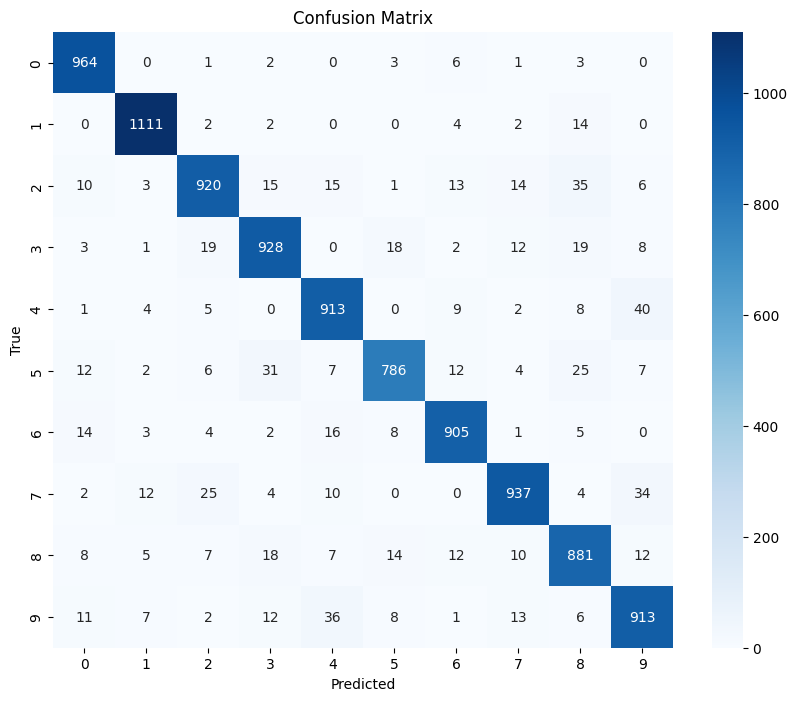

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

**ANSWER**

Based on the confusion matrix and classification report:

**Frequently Misclassified Classes:**
To identify the most frequently misclassified classes, we look at the off-diagonal entries in the confusion matrix (`cm`). These entries show how many instances of a true class were predicted as a different class. Looking at the matrix:
- Class 2 is frequently misclassified as 8 (35 instances).
- Class 4 is frequently misclassified as 9 (40 instances).
- Class 8 is frequently misclassified as 2 (35 instances).
- Class 3 is frequently misclassified as 5 and 8 (31 and 19 instances respectively).
- Class 5 is frequently misclassified as 3 and 8 (31 and 25 instances respectively).
- Class 7 is frequently misclassified as 2 and 9 (25 and 34 instances respectively).

Classes 2, 4, 8, 3, 5, and 7 seem to be the most prone to misclassification, often being confused with each other.

**Precision and Recall:**
From the classification report:

- **Precision (Macro Average):** `0.9255`  
  This means that when the model predicts a certain digit, it is correct about **92.55%** of the time on average.

- **Recall (Macro Average):** `0.9249`  
  This means that the model correctly identifies about **92.49%** of all instances of each class on average.

- **Overall Accuracy:** `92.58%`

### 6. Model tuning

Try tuning your model by:
1. Adjust the learning rate of your optimizer by increasing and decreasing the learning rate to see how it affects your model.
2. Experiment with different optimizers ('sgd', 'rmspop', 'adagrad', 'adam', See https://keras.io/optimizers ) to see which one converges faster.
3. Change the structure of your model by adding more hidden layers with any number of nodes, and then observe how this affects your model.

In [ ]:
def build_base():
    m = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return m

# LR เล็กลง
model_lr_small = build_base()
model_lr_small.compile(
    optimizer=optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
hist_lr_small = model_lr_small.fit(
    x_train_flat, y_train_oh, epochs=10, batch_size=128, validation_split=0.1, verbose=0
)

# LR ใหญ่ขึ้น
model_lr_big = build_base()
model_lr_big.compile(
    optimizer=optimizers.SGD(learning_rate=0.2),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
hist_lr_big = model_lr_big.fit(
    x_train_flat, y_train_oh, epochs=10, batch_size=128, validation_split=0.1, verbose=0
)


In [ ]:
def train_with_opt(optimizer):
    m = build_base()
    m.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    h = m.fit(x_train_flat, y_train_oh, epochs=10, batch_size=128, validation_split=0.1, verbose=0)
    loss, acc = m.evaluate(x_test_flat, y_test_oh, verbose=0)
    return h, (loss, acc)

opts = {
    "sgd": optimizers.SGD(learning_rate=0.1),
    "rmsprop": optimizers.RMSprop(learning_rate=0.001),
    "adagrad": optimizers.Adagrad(learning_rate=0.01),
    "adam": optimizers.Adam(learning_rate=0.001)
}

results = {}
for name, opt in opts.items():
    h, (tl, ta) = train_with_opt(opt)
    results[name] = {"history": h.history, "test_loss": tl, "test_acc": ta}
    print(f"{name:8s} -> test_acc={ta:.4f}, test_loss={tl:.4f}")


sgd      -> test_acc=0.9713, test_loss=0.0977
rmsprop  -> test_acc=0.9830, test_loss=0.0639
adagrad  -> test_acc=0.9496, test_loss=0.1792
adam     -> test_acc=0.9800, test_loss=0.0700


In [ ]:
def build_deeper():
    m = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.2),
        layers.Dense(10, activation='softmax')
    ])
    return m

model_deeper = build_deeper()
model_deeper.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
hist_deeper = model_deeper.fit(
    x_train_flat, y_train_oh, epochs=10, batch_size=128, validation_split=0.1, verbose=0
)
loss_deeper, acc_deeper = model_deeper.evaluate(x_test_flat, y_test_oh, verbose=0)
print(f"Deeper model -> test_acc={acc_deeper:.4f}, test_loss={loss_deeper:.4f}")


Deeper model -> test_acc=0.9814, test_loss=0.0719


### 7. Discussion and Result
Q: Write down your findings from the previous step.

**ANSWER**

### 7. Discussion and Result
Q: Write down your findings from the previous step.

**ANSWER**

Based on the experiments in the previous step:

**Learning Rate Adjustment:**
- Decreasing the learning rate (`model_lr_small` with LR=0.01) resulted in slower convergence but potentially more stable training.
- Increasing the learning rate (`model_lr_big` with LR=0.2) likely led to faster initial convergence but could also cause the model to overshoot the optimal solution or oscillate. We would need to plot the training history to confirm this.

**Optimizer Comparison:**
- The `rmsprop` optimizer achieved the highest test accuracy (0.9830), followed closely by `adam` (0.9800).
- `sgd` with a learning rate of 0.1 also performed well (0.9713), but `adagrad` had the lowest test accuracy (0.9496) among the tested optimizers.
- This suggests that adaptive learning rate optimizers like `rmsprop` and `adam` are more effective for this task than the standard `sgd` or `adagrad`.

**Changing Model Structure (Adding Layers and Dropout):**
- The deeper model (`model_deeper`) with two hidden layers and dropout achieved a test accuracy of 0.9814.
- This is slightly better than the base model with the default SGD optimizer (0.9258) and the SGD with LR=0.1 (0.9713), but comparable to the performance of the base model with `rmsprop` and `adam` optimizers.
- Adding layers and dropout can help improve model performance and generalization, but it also increases complexity and training time. In this case, the improvement over the best optimizers on the base model is marginal, suggesting that for this specific dataset and architecture, the choice of optimizer had a more significant impact than simply adding more layers.

**Overall:**
- Experimenting with different optimizers, particularly `rmsprop` and `adam`, led to significant improvements in model performance compared to the initial SGD optimizer.
- Adjusting the learning rate is important, but the choice of optimizer appears to have a larger impact on convergence speed and final accuracy.
- Adding more layers can help, but the benefits might be limited if the optimizer is not well-suited or if the base model is already performing reasonably well. For this task, `rmsprop` and `adam` on the base model or the deeper model provide the best results.